# Notebook 13: Combined 70B Augmentation — MLP-1 Only

## Purpose
Test whether combining the two best 70B augmentation strategies simultaneously
pushes MLP-1 beyond its individual condition bests:
- 70B Contrastive negatives (0.4≤τ≤0.9): F1=0.291, P=0.240
- 70B CoT positives (τ≥0.6): F1=0.292, P=0.223

## Hypothesis
The two strategies are complementary:
- Contrastive negatives sharpen the decision boundary → precision gains
- CoT positives expand positive class coverage → recall gains
Combined, they should improve both simultaneously.

## Design
- MLP-1 only (384→256→2) — best performing classifier throughout
- No LR, no MLP-2 — focused experiment, clean comparison
- Single comparison: MLP-1 baseline vs MLP-1 combined augmentation

## Augmentation
| Pool | Filter | Label | Expected survivors |
|---|---|---|---|
| 70B CoT positives | τ ≥ 0.6 | 1 | ~608 |
| 70B Contrastive negatives | 0.4 ≤ τ ≤ 0.9 | 0 | ~TBD |

## Evaluation
- Metrics: Precision, Recall, F1 vs MLP-1 baseline
- DET curve: combined vs baseline, two curves only

In [2]:
# -----------------------------------------------
# Imports and data loading
# Identical to Notebooks 09-12
# -----------------------------------------------
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    det_curve,
)
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

os.chdir("..")

# -----------------------------------------------
# Load embeddings and splits
# -----------------------------------------------
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")
X_cal   = np.load("data/processed/embeddings/X_cal.npy")
y_cal   = np.load("data/processed/embeddings/y_cal.npy")
X_test  = np.load("data/processed/embeddings/X_test.npy")
y_test  = np.load("data/processed/embeddings/y_test.npy")

print(f"Train: {X_train.shape} | Positives: {y_train.sum()}")
print(f"Cal:   {X_cal.shape}   | Positives: {y_cal.sum()}")
print(f"Test:  {X_test.shape}  | Positives: {y_test.sum()}")

# -----------------------------------------------
# Load Notebook 09 MLP-1 baseline metrics
# -----------------------------------------------
with open("data/results/metrics_09_baseline.json") as f:
    baseline_metrics = json.load(f)

m = baseline_metrics['MLP-1']
print(f"\nMLP-1 baseline: F1={m['f1']:.3f} | "
      f"P={m['precision']:.3f} | R={m['recall']:.3f}")

Train: (69510, 384) | Positives: 674
Cal:   (9931, 384)   | Positives: 96
Test:  (19861, 384)  | Positives: 192

MLP-1 baseline: F1=0.270 | P=0.190 | R=0.464


In [11]:
# -----------------------------------------------
# MLP-1 architecture, wrapper, utilities
# Identical to Notebooks 09-12 — self-contained
# -----------------------------------------------
def optimal_threshold_f1(
    y_true, y_scores,
    thresholds=np.arange(0.01, 0.70, 0.01),
):
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1


class MLP(nn.Module):
    def __init__(self, input_dim=384, hidden_dims=[256], dropout=0.1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class MLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self, hidden_dims=[256], n_epochs=50, lr=1e-3,
        batch_size=256, patience=10, dropout=0.1, random_state=SEED,
    ):
        self.hidden_dims   = hidden_dims
        self.n_epochs      = n_epochs
        self.lr            = lr
        self.batch_size    = batch_size
        self.patience      = patience
        self.dropout       = dropout
        self.random_state  = random_state
        self.classes_      = np.array([0, 1])

    def fit(self, X, y, X_cal=None, y_cal=None):
        torch.manual_seed(self.random_state)
        n_neg, n_pos = (y == 0).sum(), (y == 1).sum()
        class_weights = torch.tensor(
            [1.0 / n_neg, 1.0 / n_pos], dtype=torch.float
        )
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        self.model_ = MLP(X.shape[1], self.hidden_dims, self.dropout)
        optimizer = AdamW(
            self.model_.parameters(), lr=self.lr, weight_decay=1e-4
        )
        loader = DataLoader(
            TensorDataset(
                torch.tensor(X, dtype=torch.float),
                torch.tensor(y, dtype=torch.long),
            ),
            batch_size=self.batch_size, shuffle=True,
        )
        best_cal_f1, best_weights, no_improve = 0.0, None, 0
        for epoch in range(self.n_epochs):
            self.model_.train()
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(X_batch), y_batch)
                loss.backward()
                optimizer.step()
            if X_cal is not None and y_cal is not None:
                _, cal_f1 = optimal_threshold_f1(
                    y_cal, self.predict_proba(X_cal)[:, 1]
                )
                if cal_f1 > best_cal_f1:
                    best_cal_f1 = cal_f1
                    best_weights = {
                        k: v.clone()
                        for k, v in self.model_.state_dict().items()
                    }
                    no_improve = 0
                else:
                    no_improve += 1
                    if no_improve >= self.patience:
                        print(f"  Early stopping at epoch {epoch+1} "
                              f"(best cal F1: {best_cal_f1:.4f})")
                        break
        if best_weights is not None:
            self.model_.load_state_dict(best_weights)
        return self

    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            probs = torch.softmax(
                self.model_(torch.tensor(X, dtype=torch.float)), dim=1
            ).numpy()
        return probs

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def evaluate_mlp1(clf, X_train, y_train, X_cal, y_cal,
                  X_test, y_test, name="MLP-1"):
    clf.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)
    cal_scores  = clf.predict_proba(X_cal)[:, 1]
    t, _        = optimal_threshold_f1(y_cal, cal_scores)
    test_scores = clf.predict_proba(X_test)[:, 1]
    y_pred      = (test_scores >= t).astype(int)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f"\n=== {name} (threshold={t:.2f}) ===")
    print(classification_report(y_test, y_pred, digits=3))
    return {
        'name': name, 'clf': clf, 'threshold': t,
        'test_scores': test_scores, 'y_pred': y_pred,
        'precision': prec, 'recall': rec, 'f1': f1,
    }

print("MLP-1 class and utilities defined.")

MLP-1 class and utilities defined.


In [4]:
# -----------------------------------------------
# Load, encode and filter both synthetic pools
# CoT positives: τ ≥ 0.6 (label=1)
# Contrastive negatives: 0.4 ≤ τ ≤ 0.9 (label=0)
# Filter reference: all 674 real positive embeddings
# -----------------------------------------------
encoder    = SentenceTransformer('all-MiniLM-L6-v2')
X_real_pos = X_train[y_train == 1]  # (674, 384)

# -----------------------------------------------
# CoT positives
# -----------------------------------------------
df_cot  = pd.read_parquet("data/synthetic/positive_cot_70b_raw.parquet")
print(f"CoT candidates: {len(df_cot)}")

X_cot      = encoder.encode(
    df_cot['sentence'].tolist(),
    show_progress_bar=False, convert_to_numpy=True,
)
sim_cot    = cosine_similarity(X_cot, X_real_pos).max(axis=1)
mask_cot   = sim_cot >= 0.6
X_cot_filt = X_cot[mask_cot]
y_cot_filt = np.ones(mask_cot.sum(), dtype=int)

print(f"CoT survivors (τ≥0.6): {mask_cot.sum()} / {len(df_cot)} "
      f"({100*mask_cot.mean():.1f}%)")

# -----------------------------------------------
# Contrastive negatives
# -----------------------------------------------
df_cont  = pd.read_parquet("data/synthetic/hard_contrastive_70b_raw.parquet")
print(f"\nContrastive candidates: {len(df_cont)}")

X_cont      = encoder.encode(
    df_cont['sentence'].tolist(),
    show_progress_bar=False, convert_to_numpy=True,
)
sim_cont    = cosine_similarity(X_cont, X_real_pos).max(axis=1)
mask_cont   = (sim_cont >= 0.4) & (sim_cont <= 0.9)
X_cont_filt = X_cont[mask_cont]
y_cont_filt = np.zeros(mask_cont.sum(), dtype=int)

print(f"Contrastive survivors (0.4≤τ≤0.9): {mask_cont.sum()} / {len(df_cont)} "
      f"({100*mask_cont.mean():.1f}%)")

# -----------------------------------------------
# Combined augmented training set
# -----------------------------------------------
X_train_combined = np.vstack([X_train, X_cot_filt, X_cont_filt])
y_train_combined = np.concatenate([y_train, y_cot_filt, y_cont_filt])

print(f"\nCombined training set: {X_train_combined.shape}")
print(f"Positives: {y_train_combined.sum()} | "
      f"Negatives: {(y_train_combined==0).sum()} | "
      f"Ratio: {(y_train_combined==0).sum()/y_train_combined.sum():.1f}:1")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 558.89it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CoT candidates: 674
CoT survivors (τ≥0.6): 608 / 674 (90.2%)

Contrastive candidates: 673
Contrastive survivors (0.4≤τ≤0.9): 651 / 673 (96.7%)

Combined training set: (70769, 384)
Positives: 1282 | Negatives: 69487 | Ratio: 54.2:1


Fitting UMAP...
Done.


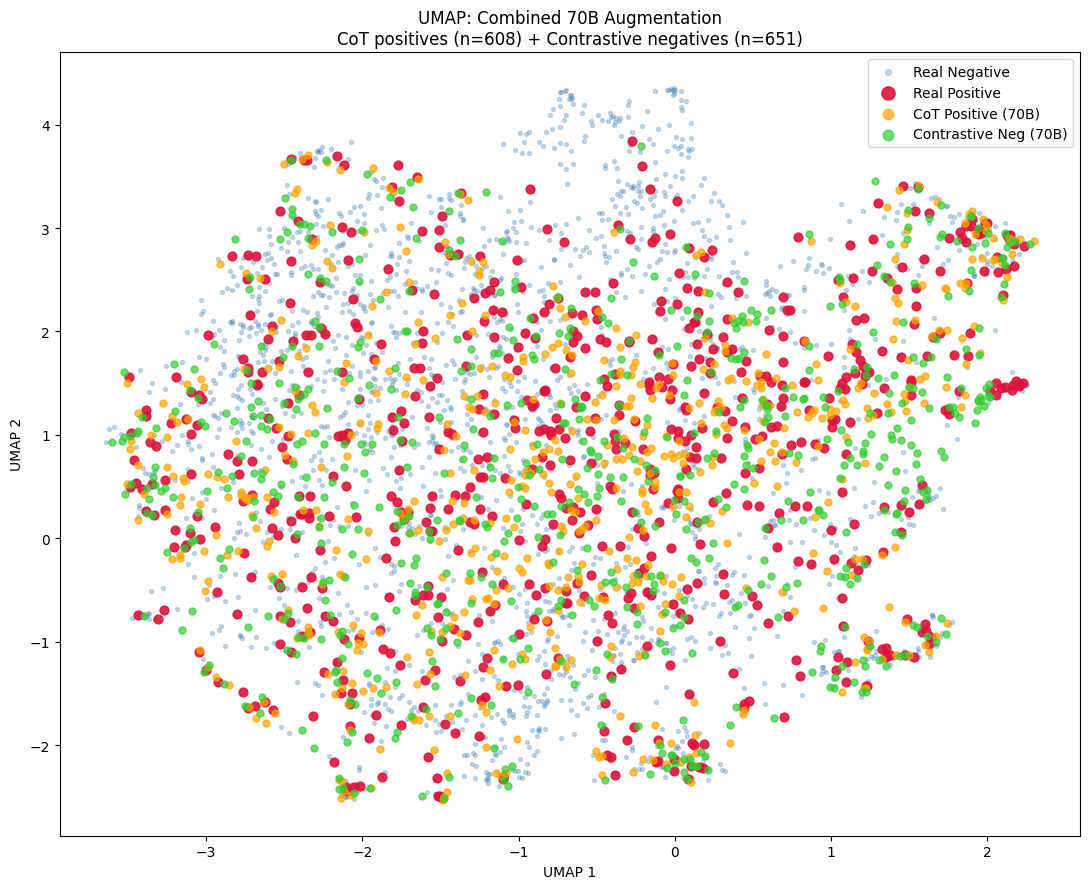

UMAP saved.


In [5]:
# -----------------------------------------------
# UMAP: all four categories overlaid
# Real positive, real negative, CoT positive,
# contrastive negative — single plot
# -----------------------------------------------
np.random.seed(SEED)
pos_idx        = np.where(y_train == 1)[0]
neg_idx        = np.where(y_train == 0)[0]
neg_sample_idx = np.random.choice(neg_idx, size=2000, replace=False)

X_plot = np.vstack([
    X_train[pos_idx],
    X_train[neg_sample_idx],
    X_cot_filt,
    X_cont_filt,
])
y_plot = (
    ['Real Positive']        * len(pos_idx) +
    ['Real Negative']        * len(neg_sample_idx) +
    ['CoT Positive (70B)']   * len(X_cot_filt) +
    ['Contrastive Neg (70B)'] * len(X_cont_filt)
)

print("Fitting UMAP...")
reducer   = umap.UMAP(n_components=2, random_state=SEED,
                      n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(X_plot)
print("Done.")

color_map = {
    'Real Negative':         'steelblue',
    'Real Positive':         'crimson',
    'CoT Positive (70B)':    'orange',
    'Contrastive Neg (70B)': 'limegreen',
}
size_map = {
    'Real Negative':         8,
    'Real Positive':         40,
    'CoT Positive (70B)':    25,
    'Contrastive Neg (70B)': 25,
}
alpha_map = {
    'Real Negative':         0.3,
    'Real Positive':         0.9,
    'CoT Positive (70B)':    0.7,
    'Contrastive Neg (70B)': 0.7,
}

fig, ax = plt.subplots(figsize=(11, 9))
for cat in ['Real Negative', 'Real Positive',
            'CoT Positive (70B)', 'Contrastive Neg (70B)']:
    mask = np.array(y_plot) == cat
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=color_map[cat], s=size_map[cat],
        alpha=alpha_map[cat], label=cat,
    )

ax.set_title(
    f'UMAP: Combined 70B Augmentation\n'
    f'CoT positives (n={mask_cot.sum()}) + '
    f'Contrastive negatives (n={mask_cont.sum()})',
    fontsize=12,
)
ax.legend(fontsize=10, markerscale=1.5)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.savefig("data/results/umap_combined_70b.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("UMAP saved.")

In [12]:
# -----------------------------------------------
# Train MLP-1 on combined augmented training set
# Single condition — compare directly to baseline
# -----------------------------------------------
print("Training MLP-1 on combined 70B augmented set...")
print(f"Training set: {X_train_combined.shape} | "
      f"Positives: {y_train_combined.sum()} | "
      f"Negatives: {(y_train_combined==0).sum()}")

result_combined = evaluate_mlp1(
    MLPClassifier(hidden_dims=[256], random_state=SEED),
    X_train_combined, y_train_combined,
    X_cal, y_cal, X_test, y_test,
    name="MLP-1 (Combined 70B)",
)

# -----------------------------------------------
# Summary table — baseline vs combined
# -----------------------------------------------
print("\n" + "=" * 65)
print(f"{'Condition':<30} {'Threshold':>10} {'P':>8} {'R':>8} {'F1':>8}")
print("-" * 65)
m = baseline_metrics['MLP-1']
print(f"{'MLP-1 Baseline':<30} {m['threshold']:>10.2f} "
      f"{m['precision']:>8.3f} {m['recall']:>8.3f} {m['f1']:>8.3f}")
print(f"{'MLP-1 70B Contrastive only':<30} {'0.60':>10} "
      f"{'0.240':>8} {'0.370':>8} {'0.291':>8}")
print(f"{'MLP-1 70B CoT only':<30} {'0.59':>10} "
      f"{'0.223':>8} {'0.422':>8} {'0.292':>8}")
print(f"{'MLP-1 Combined 70B':<30} "
      f"{result_combined['threshold']:>10.2f} "
      f"{result_combined['precision']:>8.3f} "
      f"{result_combined['recall']:>8.3f} "
      f"{result_combined['f1']:>8.3f}")
print("=" * 65)

Training MLP-1 on combined 70B augmented set...
Training set: (70769, 384) | Positives: 1282 | Negatives: 69487
  Early stopping at epoch 28 (best cal F1: 0.2441)

=== MLP-1 (Combined 70B) (threshold=0.67) ===
              precision    recall  f1-score   support

           0      0.995     0.970     0.983     19669
           1      0.153     0.547     0.239       192

    accuracy                          0.966     19861
   macro avg      0.574     0.759     0.611     19861
weighted avg      0.987     0.966     0.976     19861


Condition                       Threshold        P        R       F1
-----------------------------------------------------------------
MLP-1 Baseline                       0.69    0.190    0.464    0.270
MLP-1 70B Contrastive only           0.60    0.240    0.370    0.291
MLP-1 70B CoT only                   0.59    0.223    0.422    0.292
MLP-1 Combined 70B                   0.67    0.153    0.547    0.239


In [13]:
# -----------------------------------------------
# Train MLP-2 on combined augmented set
# MLP-2 has consistently benefited from volume
# throughout this project — worth testing here
# -----------------------------------------------
print("Training MLP-2 on combined 70B augmented set...")

result_combined_mlp2 = evaluate_mlp1(
    MLPClassifier(hidden_dims=[256, 128], random_state=SEED),
    X_train_combined, y_train_combined,
    X_cal, y_cal, X_test, y_test,
    name="MLP-2 (Combined 70B)",
)

# -----------------------------------------------
# Updated summary table
# -----------------------------------------------
print("\n" + "=" * 65)
print(f"{'Condition':<30} {'Threshold':>10} {'P':>8} {'R':>8} {'F1':>8}")
print("-" * 65)

rows = [
    ("MLP-1 Baseline",            0.69, 0.190, 0.464, 0.270),
    ("MLP-2 Baseline",            0.69, 0.134, 0.448, 0.207),
    ("MLP-1 70B Contrastive",     0.60, 0.240, 0.370, 0.291),
    ("MLP-1 70B CoT",             0.59, 0.223, 0.422, 0.292),
    ("MLP-1 Combined 70B",        result_combined['threshold'],
     result_combined['precision'], result_combined['recall'],
     result_combined['f1']),
    ("MLP-2 Combined 70B",        result_combined_mlp2['threshold'],
     result_combined_mlp2['precision'], result_combined_mlp2['recall'],
     result_combined_mlp2['f1']),
]

for name, t, p, r, f1 in rows:
    print(f"{name:<30} {t:>10.2f} {p:>8.3f} {r:>8.3f} {f1:>8.3f}")
print("=" * 65)

Training MLP-2 on combined 70B augmented set...
  Early stopping at epoch 19 (best cal F1: 0.2254)

=== MLP-2 (Combined 70B) (threshold=0.65) ===
              precision    recall  f1-score   support

           0      0.995     0.978     0.986     19669
           1      0.167     0.448     0.243       192

    accuracy                          0.973     19861
   macro avg      0.581     0.713     0.615     19861
weighted avg      0.987     0.973     0.979     19861


Condition                       Threshold        P        R       F1
-----------------------------------------------------------------
MLP-1 Baseline                       0.69    0.190    0.464    0.270
MLP-2 Baseline                       0.69    0.134    0.448    0.207
MLP-1 70B Contrastive                0.60    0.240    0.370    0.291
MLP-1 70B CoT                        0.59    0.223    0.422    0.292
MLP-1 Combined 70B                   0.67    0.153    0.547    0.239
MLP-2 Combined 70B                   0.65    0

Retraining MLP-1 baseline for DET reference...
  Early stopping at epoch 30 (best cal F1: 0.2541)
Done.


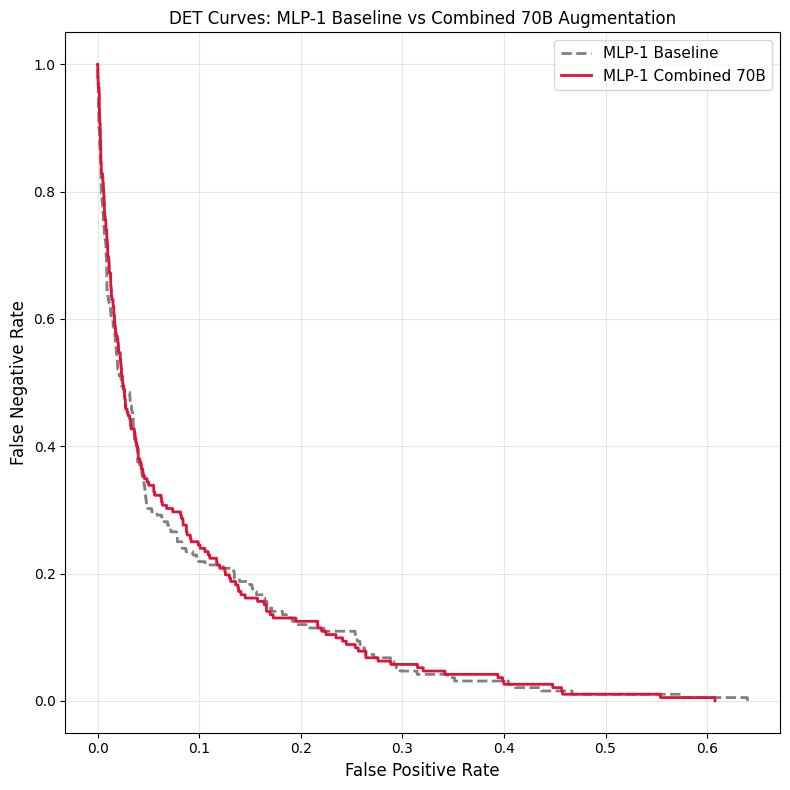

DET curves saved.
Metrics saved to data/results/metrics_13_combined_70b.json

Notebook 13 complete. Line drawn.


In [14]:
# -----------------------------------------------
# DET curves — MLP-1 baseline vs combined 70B
# Two curves only — clean comparison
# -----------------------------------------------

# Retrain MLP-1 baseline for DET reference scores
print("Retraining MLP-1 baseline for DET reference...")
clf_base = MLPClassifier(hidden_dims=[256], random_state=SEED)
clf_base.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)
scores_base = clf_base.predict_proba(X_test)[:, 1]
print("Done.")

fig, ax = plt.subplots(figsize=(8, 8))

# Baseline
fpr, fnr, _ = det_curve(y_test, scores_base)
ax.plot(fpr, fnr, color='gray', linestyle='--',
        linewidth=2, label='MLP-1 Baseline')

# Combined 70B
fpr, fnr, _ = det_curve(y_test, result_combined['test_scores'])
ax.plot(fpr, fnr, color='crimson', linestyle='-',
        linewidth=2, label='MLP-1 Combined 70B')

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("False Negative Rate", fontsize=12)
ax.set_title("DET Curves: MLP-1 Baseline vs Combined 70B Augmentation",
             fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/results/det_curves_13_combined.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("DET curves saved.")

# -----------------------------------------------
# Save metrics
# -----------------------------------------------
metrics_13 = {
    'MLP-1 Combined 70B': {
        'precision': round(result_combined['precision'], 4),
        'recall':    round(result_combined['recall'], 4),
        'f1':        round(result_combined['f1'], 4),
        'threshold': round(result_combined['threshold'], 4),
    },
    'MLP-2 Combined 70B': {
        'precision': round(result_combined_mlp2['precision'], 4),
        'recall':    round(result_combined_mlp2['recall'], 4),
        'f1':        round(result_combined_mlp2['f1'], 4),
        'threshold': round(result_combined_mlp2['threshold'], 4),
    },
}

with open("data/results/metrics_13_combined_70b.json", "w") as f:
    json.dump(metrics_13, f, indent=2)
print("Metrics saved to data/results/metrics_13_combined_70b.json")
print("\nNotebook 13 complete. Line drawn.")